In [3]:
# ==========================================================
# 01. Google Drive 연결
# ==========================================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ==========================================================
# 02. 라이브러리 설치
# ==========================================================

!pip install -q tensorflow scikit-learn matplotlib

In [5]:
# ==========================================================
# 03. GPU 확인
# ==========================================================

import tensorflow as tf

print("TensorFlow :", tf.__version__)
print("GPU :", tf.config.list_physical_devices('GPU'))

!nvidia-smi

TensorFlow : 2.20.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mon Aug 24 04:33:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |    

In [6]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

In [7]:
# ==========================================================
# 04. 데이터 확인
# ==========================================================

import os

DATA_ROOT = "/content/drive/MyDrive/blueberry_crop"

READY_DIR = os.path.join(DATA_ROOT, "ready")
NOT_READY_DIR = os.path.join(DATA_ROOT, "not_ready")

ready_files = [
    os.path.join(READY_DIR, f)
    for f in os.listdir(READY_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

not_ready_files = [
    os.path.join(NOT_READY_DIR, f)
    for f in os.listdir(NOT_READY_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Ready :", len(ready_files))
print("Not Ready :", len(not_ready_files))
print("Total :", len(ready_files) + len(not_ready_files))

Ready : 19145
Not Ready : 32768
Total : 51913


In [8]:
# ==========================================================
# 05. tf.data 데이터셋 설정 + Train / Validation / Test 분리
# ==========================================================
#
# [참고] 원래 노트북에는 이 아래에 "06. Train/Validation/Test 분리"라는
#        이름으로 val_files/test_files를 다른 비율(70/15/15)로, 심지어
#        전처리 없이 다시 만드는 중복 셀들이 있었습니다.
#        EfficientNet은 preprocess_input이 아무 일도 안 하는 함수라
#        묻혔지만, 지금 이 CNN은 실제 정규화가 필요하므로 그 중복 셀들은
#        삭제하고 아래 split 하나만 씁니다 (train/val/test 8000/1000/1000).

import tensorflow as tf
import random
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------
# 설정
# ----------------------------------------------------------

IMAGE_SIZE = (96, 96)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

SAMPLE_PER_CLASS = 5000

SEED = 42

random.seed(SEED)

# ----------------------------------------------------------
# 클래스별 랜덤 샘플링
# ----------------------------------------------------------

ready_files = random.sample(
    ready_files,
    min(SAMPLE_PER_CLASS, len(ready_files))
)

not_ready_files = random.sample(
    not_ready_files,
    min(SAMPLE_PER_CLASS, len(not_ready_files))
)

files = ready_files + not_ready_files

labels = [1] * len(ready_files) + [0] * len(not_ready_files)

# ----------------------------------------------------------
# Train / Validation / Test
# ----------------------------------------------------------

train_files, temp_files, train_labels, temp_labels = train_test_split(
    files,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print(f"Train      : {len(train_files)}")
print(f"Validation : {len(val_files)}")
print(f"Test       : {len(test_files)}")

Train      : 8000
Validation : 1000
Test       : 1000


In [9]:
# ----------------------------------------------------------
# 이미지 읽기
# ----------------------------------------------------------

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

In [10]:
# ==========================================================
# Data Augmentation
# ==========================================================

data_augmentation = tf.keras.Sequential([

    # 좌우 반전
    tf.keras.layers.RandomFlip("horizontal"),

    # 약간의 회전 (±18° 정도)
    tf.keras.layers.RandomRotation(0.05),

    # 약간 확대/축소
    tf.keras.layers.RandomZoom(0.10),

    # 좌우/상하 위치 이동
    tf.keras.layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    # 밝기 변화
    tf.keras.layers.RandomBrightness(0.15),

    # 대비 변화
    tf.keras.layers.RandomContrast(0.15),

], name="data_augmentation")

In [11]:
# ----------------------------------------------------------
# 정규화 전처리 (Simple CNN)
#
# [변경] EfficientNet은 모델 안에 Rescaling+Normalization이
#        내장되어 있어서 preprocess_input()이 사실상 아무 일도
#        하지 않는 함수였습니다 (0~255 그대로 통과).
#        지금 쓰는 건 사전학습 없는 일반 CNN이라 내장 정규화가
#        없으므로, 여기서 직접 [0, 1] 범위로 정규화합니다.
# ----------------------------------------------------------

def preprocess(image, label):
    image = image / 255.0
    return image, label

In [12]:
# ----------------------------------------------------------
# Dataset 생성
# ----------------------------------------------------------

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_files, train_labels)
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

# 학습 데이터만 증강
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.shuffle(
    1000,
    seed=SEED
)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(AUTOTUNE)

In [13]:
validation_dataset = tf.data.Dataset.from_tensor_slices(
    (val_files, val_labels)
)

validation_dataset = validation_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

validation_dataset = validation_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

validation_dataset = validation_dataset.batch(BATCH_SIZE)

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [14]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_files, test_labels)
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.prefetch(AUTOTUNE)

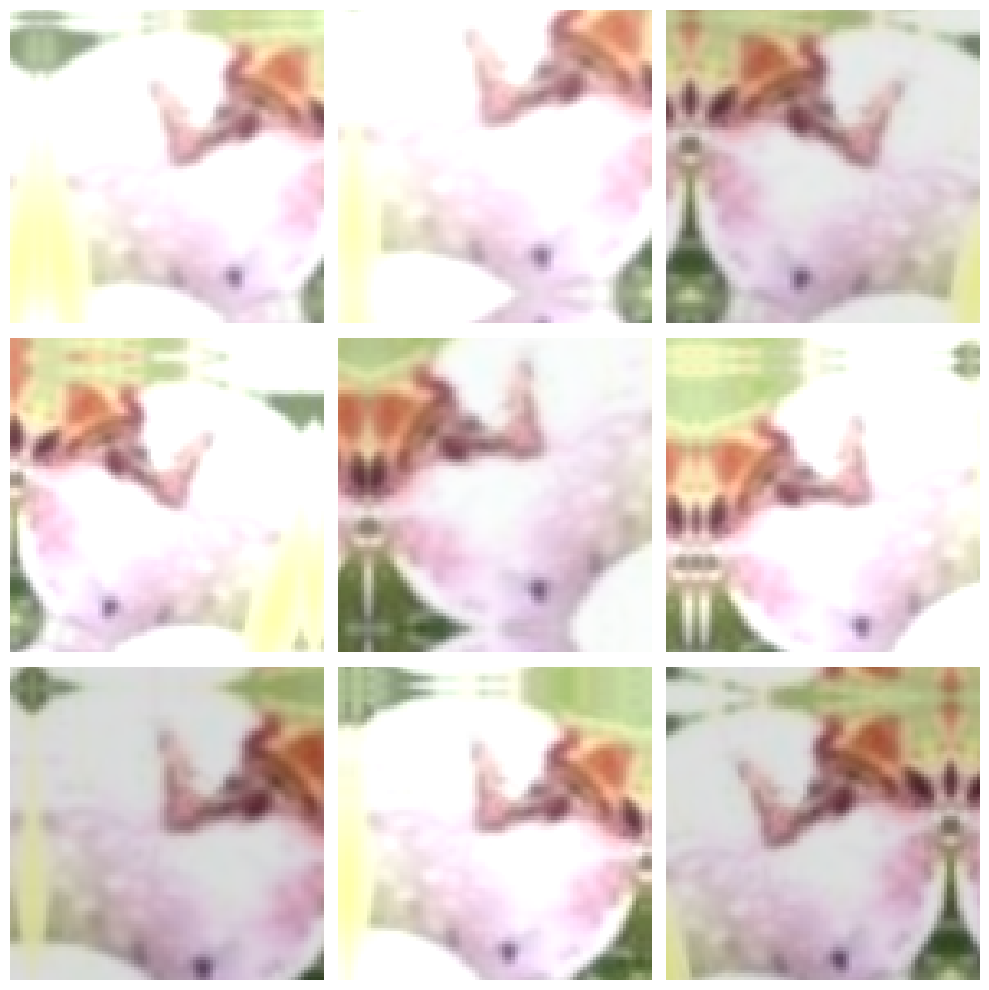

In [15]:
# ==========================================================
# 증강 이미지 확인
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

sample_path = train_files[0]

image = tf.io.read_file(sample_path)
image = tf.image.decode_jpeg(image, channels=3)
image = tf.image.resize(image, IMAGE_SIZE)
image = tf.cast(image, tf.float32)

plt.figure(figsize=(10, 10))

for i in range(9):
    aug = data_augmentation(image, training=True)
    aug = tf.cast(aug, tf.float32)
    aug = tf.clip_by_value(aug / 255.0, 0, 1)

    plt.subplot(3, 3, i + 1)
    plt.imshow(aug.numpy())
    plt.axis("off")

plt.tight_layout()
plt.show()

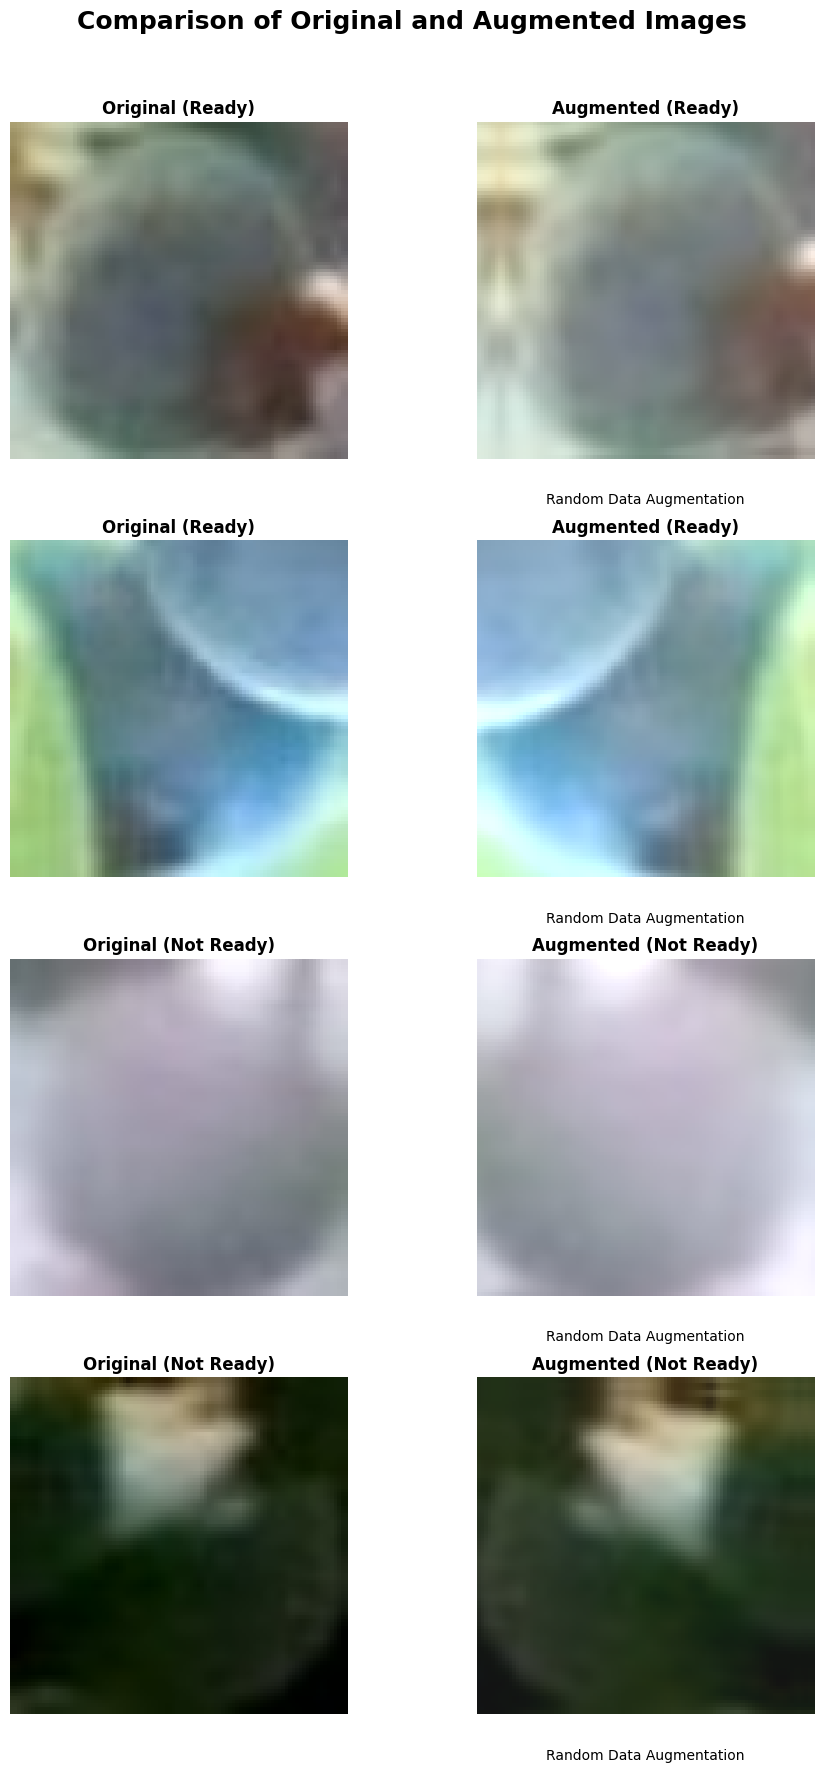

In [16]:
# ==========================================================
# Original vs Augmented Images (Final)
# ==========================================================

import tensorflow as tf
import matplotlib.pyplot as plt
import random

# Ready / Not Ready 이미지 분리
ready_paths = [f for f, l in zip(train_files, train_labels) if l == 1]
not_ready_paths = [f for f, l in zip(train_files, train_labels) if l == 0]

# 각 클래스에서 2장씩 랜덤 선택
sample_paths = (
    random.sample(ready_paths, 2) +
    random.sample(not_ready_paths, 2)
)

sample_labels = (
    ["Ready"] * 2 +
    ["Not Ready"] * 2
)

def load_image_for_display(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image

fig, axes = plt.subplots(4, 2, figsize=(10, 18))

for i, (path, label) in enumerate(zip(sample_paths, sample_labels)):
    img = load_image_for_display(path)

    aug = data_augmentation(img, training=True)
    aug = tf.cast(aug, tf.float32)

    img_show = tf.clip_by_value(img / 255.0, 0, 1)
    aug_show = tf.clip_by_value(aug / 255.0, 0, 1)

    axes[i, 0].imshow(img_show.numpy())
    axes[i, 0].set_title(f"Original ({label})", fontsize=12, fontweight="bold")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(aug_show.numpy())
    axes[i, 1].set_title(f"Augmented ({label})", fontsize=12, fontweight="bold")
    axes[i, 1].text(
        0.5, -0.10, "Random Data Augmentation",
        ha="center", va="top", fontsize=10,
        transform=axes[i, 1].transAxes
    )
    axes[i, 1].axis("off")

plt.suptitle("Comparison of Original and Augmented Images", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [17]:
# ==========================================================
# 07. Simple CNN 모델 생성
# ==========================================================
#
# [변경] EfficientNetB0(ImageNet 사전학습) 대신, 사전학습 없는
#        일반 CNN을 처음부터 학습시킵니다.
#        현재 데이터는 익음/안익음이 질감보다 "전체적인 색상"으로
#        갈리는 경향이 커서(RGB 채널 평균이 클래스 간 30~40 차이),
#        깊고 복잡한 사전학습 특징보다 이런 가벼운 구조가
#        오히려 더 안정적으로 색상 신호를 잡아낼 수 있습니다.
# ----------------------------------------------------------

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

inputs = layers.Input(shape=(*IMAGE_SIZE, 3))

# Block 1: 96 -> 48
x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# Block 2: 48 -> 24
x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# Block 3: 24 -> 12
x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# Block 4: 12 그대로 유지 (Grad-CAM이 참조할 마지막 conv layer)
x = layers.Conv2D(128, 3, padding="same", activation="relu", name="last_conv")(x)
x = layers.BatchNormalization()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation="sigmoid", dtype="float32")(x)

model = Model(inputs=inputs, outputs=output, name="blueberry_simple_cnn")

model.summary()

Model: "blueberry_simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,881 (1011.25 KB)

 Trainable params: 258,177 (1008.50 KB)

 Non-trainable params: 704 (2.75 KB)

In [18]:
# ==========================================================
# 09. EarlyStopping
# ==========================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [19]:
# ==========================================================
# 10. Learning Rate Scheduler
# ReduceLROnPlateau보다 조금 더 성능이 좋은 Cosine Decay
# ==========================================================
#
# [변경] 원래는 15에폭(1차) + 5에폭(2차, 파인튜닝) 구조라
#        decay_steps=1000으로 1차 학습 초반에 빠르게 감쇠시켰습니다.
#        지금은 파인튜닝 없이 한 번에 처음부터 학습하므로,
#        전체 학습 구간(최대 40에폭 * 250 step)에 걸쳐 천천히
#        감쇠하도록 decay_steps를 늘렸습니다.

import tensorflow as tf

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=6000,
    alpha=1e-6
)

In [20]:
# ==========================================================
# 모델 Compile
# ==========================================================

from tensorflow.keras.metrics import Precision, Recall, AUC

model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

In [21]:
# ==========================================================
# 11. ModelCheckpoint
# ==========================================================

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath="best_blueberry_cnn_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [22]:
# ==========================================================
# 12. 모델 학습
# ==========================================================
#
# [변경] EfficientNet 버전은 Feature Extraction(1차) + Fine-Tuning(2차)
#        두 단계였지만, 사전학습된 가중치가 없는 일반 CNN은
#        "얼렸다가 풀어줄" 레이어 자체가 없으므로 한 번에 학습합니다.
#        대신 처음부터 배우는 만큼 epoch을 늘리고, EarlyStopping이
#        val_loss 기준으로 알아서 멈추도록 둡니다.

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=40,
    callbacks=[
        checkpoint,
        early_stop
    ]
)

Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9015 - auc: 0.9609 - loss: 0.2472 - precision: 0.9269 - recall: 0.8717 
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_blueberry_cnn_model.keras

Epoch 1: finished saving model to best_blueberry_cnn_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 1618s 6s/step - accuracy: 0.9164 - auc: 0.9705 - loss: 0.2166 - precision: 0.9332 - recall: 0.8970 - val_accuracy: 0.5000 - val_auc: 0.9804 - val_loss: 1.6668 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9371 - auc: 0.9826 - loss: 0.1645 - precision: 0.9494 - recall: 0.9231
Epoch 2: val_accuracy improved from 0.50000 to 0.81000, saving model to best_blueberry_cnn_model.keras

Epoch 2: finished saving model to best_blueberry_cnn_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step - accuracy: 0.9336 - auc: 0.9813 - loss: 0.1722 - precision: 0.9446 - recall: 0.9212 - val_accuracy: 0.8

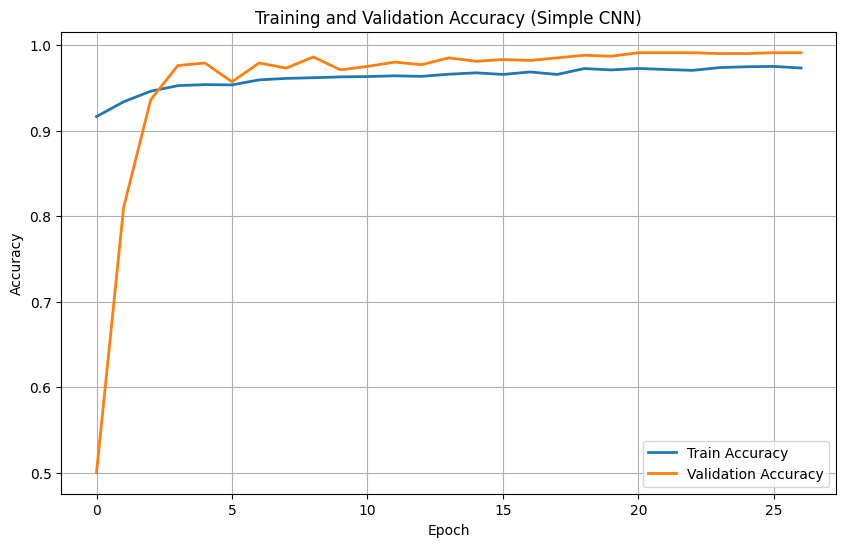

In [23]:
# ==========================================================
# 13. Accuracy 그래프
# ==========================================================

import matplotlib.pyplot as plt

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(10, 6))

plt.plot(train_acc, label="Train Accuracy", linewidth=2)
plt.plot(val_acc, label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (Simple CNN)")

plt.legend()
plt.grid(True)
plt.show()

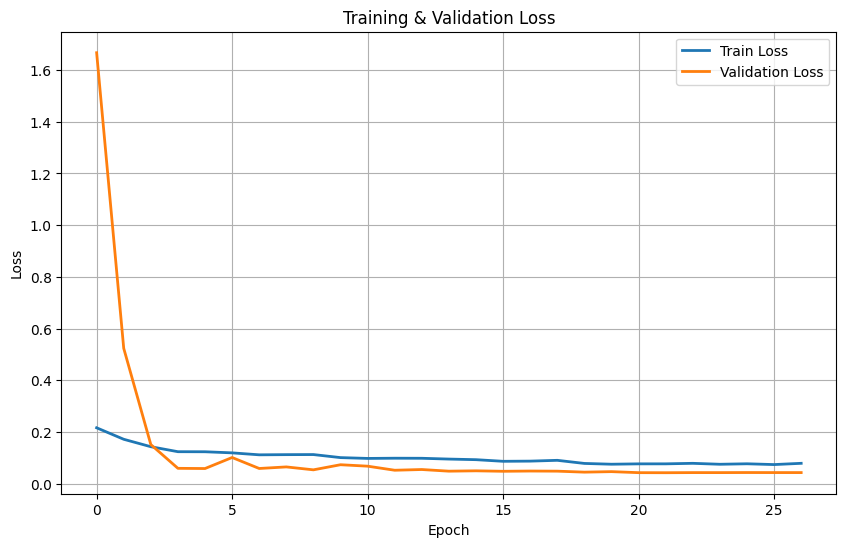

In [24]:
# ==========================================================
# 14. Loss 그래프
# ==========================================================

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(10, 6))

plt.plot(train_loss, label="Train Loss", linewidth=2)
plt.plot(val_loss, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [25]:
# ==========================================================
# Validation 예측
# ==========================================================

import numpy as np

y_true = np.array(val_labels)

y_prob = model.predict(validation_dataset)

y_pred = (y_prob > 0.5).astype(int).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step


In [26]:
# ==========================================================
# 15. Precision
# ==========================================================

from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred)

print(f"Precision : {precision:.4f}")

Precision : 0.9900


In [27]:
# ==========================================================
# 16. Recall
# ==========================================================

from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred)

print(f"Recall : {recall:.4f}")

Recall : 0.9920


In [28]:
# ==========================================================
# 17. F1-score
# ==========================================================

from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)

print(f"F1-score : {f1:.4f}")

F1-score : 0.9910


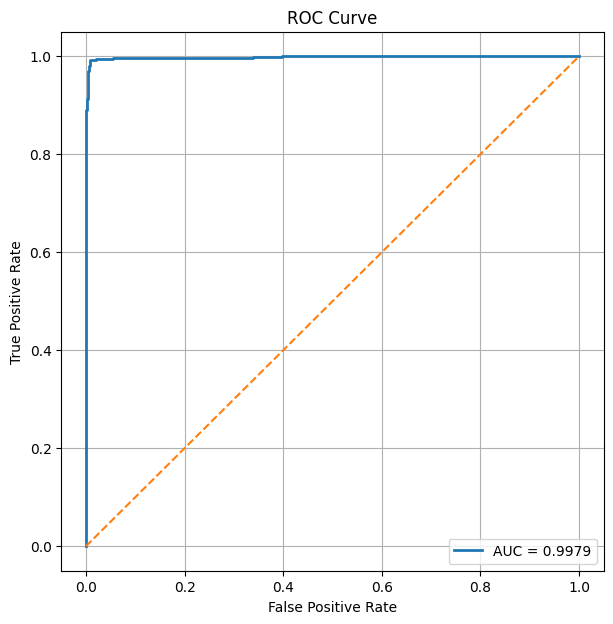

In [29]:
# ==========================================================
# 18. ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)
plt.show()

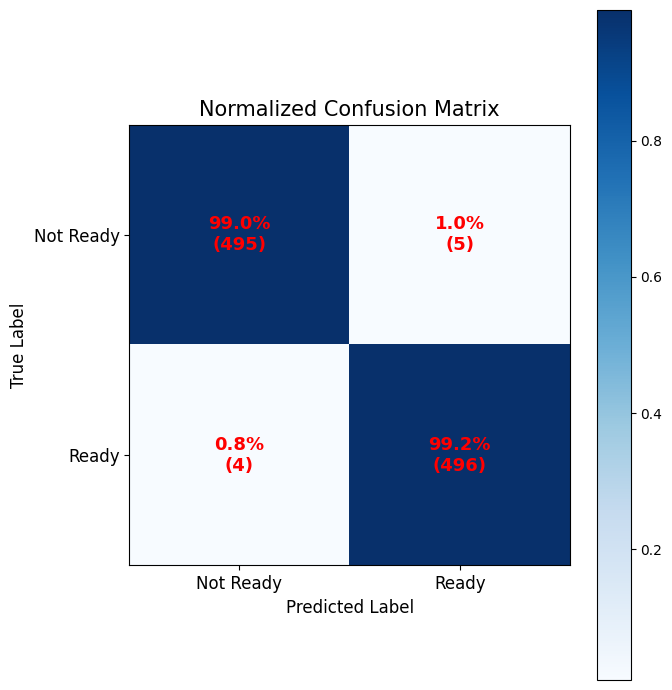

In [30]:
# ==========================================================
# 19. Normalized Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 7))
plt.imshow(cm_percent, cmap="Blues")
plt.colorbar()

classes = ["Not Ready", "Ready"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            f"{cm_percent[i, j]*100:.1f}%\n({cm[i, j]})",
            ha="center", va="center",
            fontsize=13, color="red", fontweight="bold"
        )

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Normalized Confusion Matrix", fontsize=15)

plt.tight_layout()
plt.show()

In [31]:
# ==========================================================
# Test 데이터 예측
# ==========================================================

test_images = []
test_labels_arr = []

for images, labels in test_dataset:
    test_images.append(images)
    test_labels_arr.append(labels)

test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels_arr)

pred_prob = model.predict(test_dataset)

pred_label = (pred_prob > 0.5).astype(int).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


오분류 개수 : 21


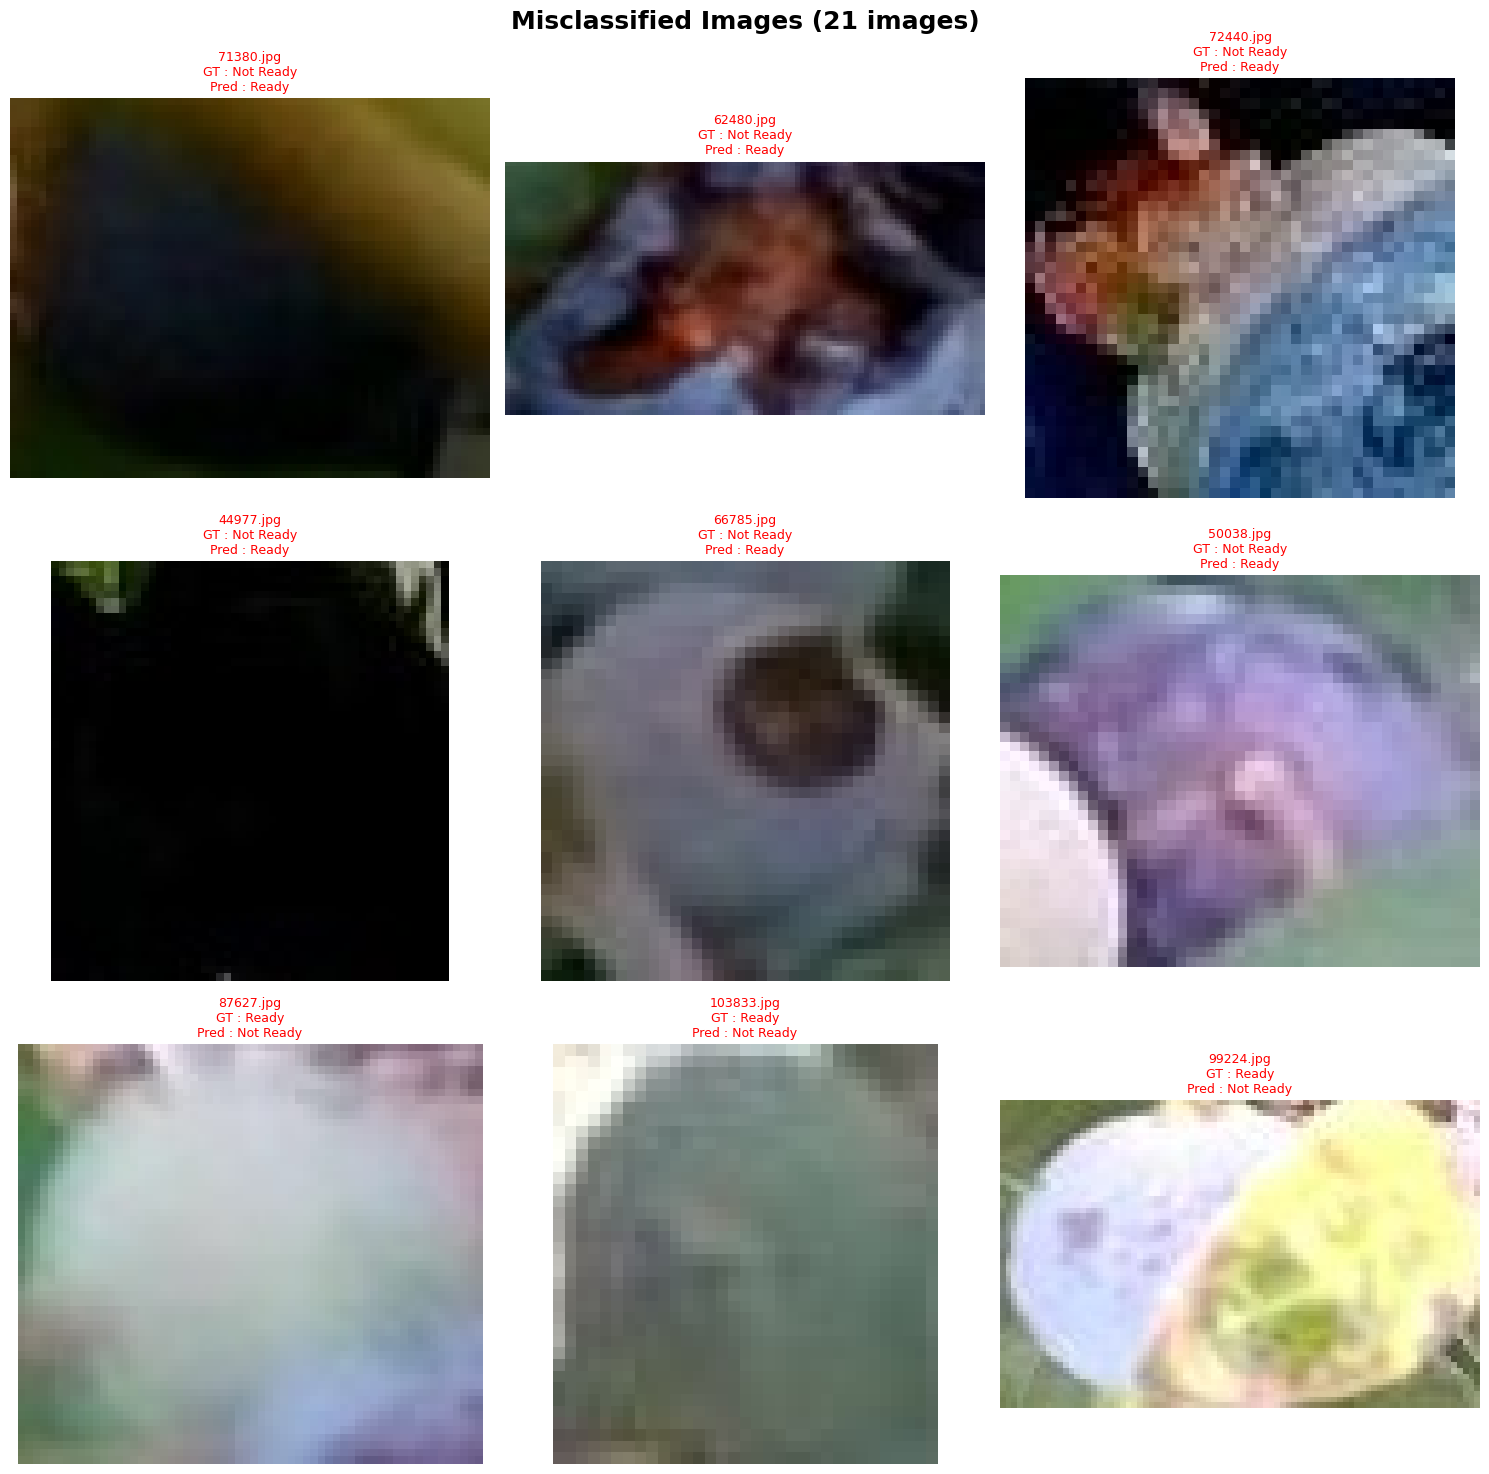

In [32]:
# ==========================================================
# 20. 오분류 이미지 (원본 이미지 표시)
# ==========================================================

import cv2
import matplotlib.pyplot as plt
import numpy as np

wrong = np.where(pred_label != test_labels)[0]

print("오분류 개수 :", len(wrong))

show_num = min(9, len(wrong))

plt.figure(figsize=(15, 15))

for i in range(show_num):
    idx = wrong[i]

    img = cv2.imread(test_files[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)

    true_label = "Ready" if test_labels[idx] == 1 else "Not Ready"
    pred = "Ready" if pred_label[idx] == 1 else "Not Ready"

    import os
    filename = os.path.basename(test_files[idx])

    plt.title(f"{filename}\nGT : {true_label}\nPred : {pred}", fontsize=9, color="red")
    plt.axis("off")

plt.suptitle(f"Misclassified Images ({len(wrong)} images)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

재사용: pred_prob (1000,), pred_label (1000,)
[1/2] Best Correct 처리 중...


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_7']
Received: inputs=Tensor(shape=(1, 96, 96, 3))
  warnings.warn(msg)


[2/2] Hardest Wrong 처리 중...


/tmp/ipykernel_528/3078811965.py:170: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_528/3078811965.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


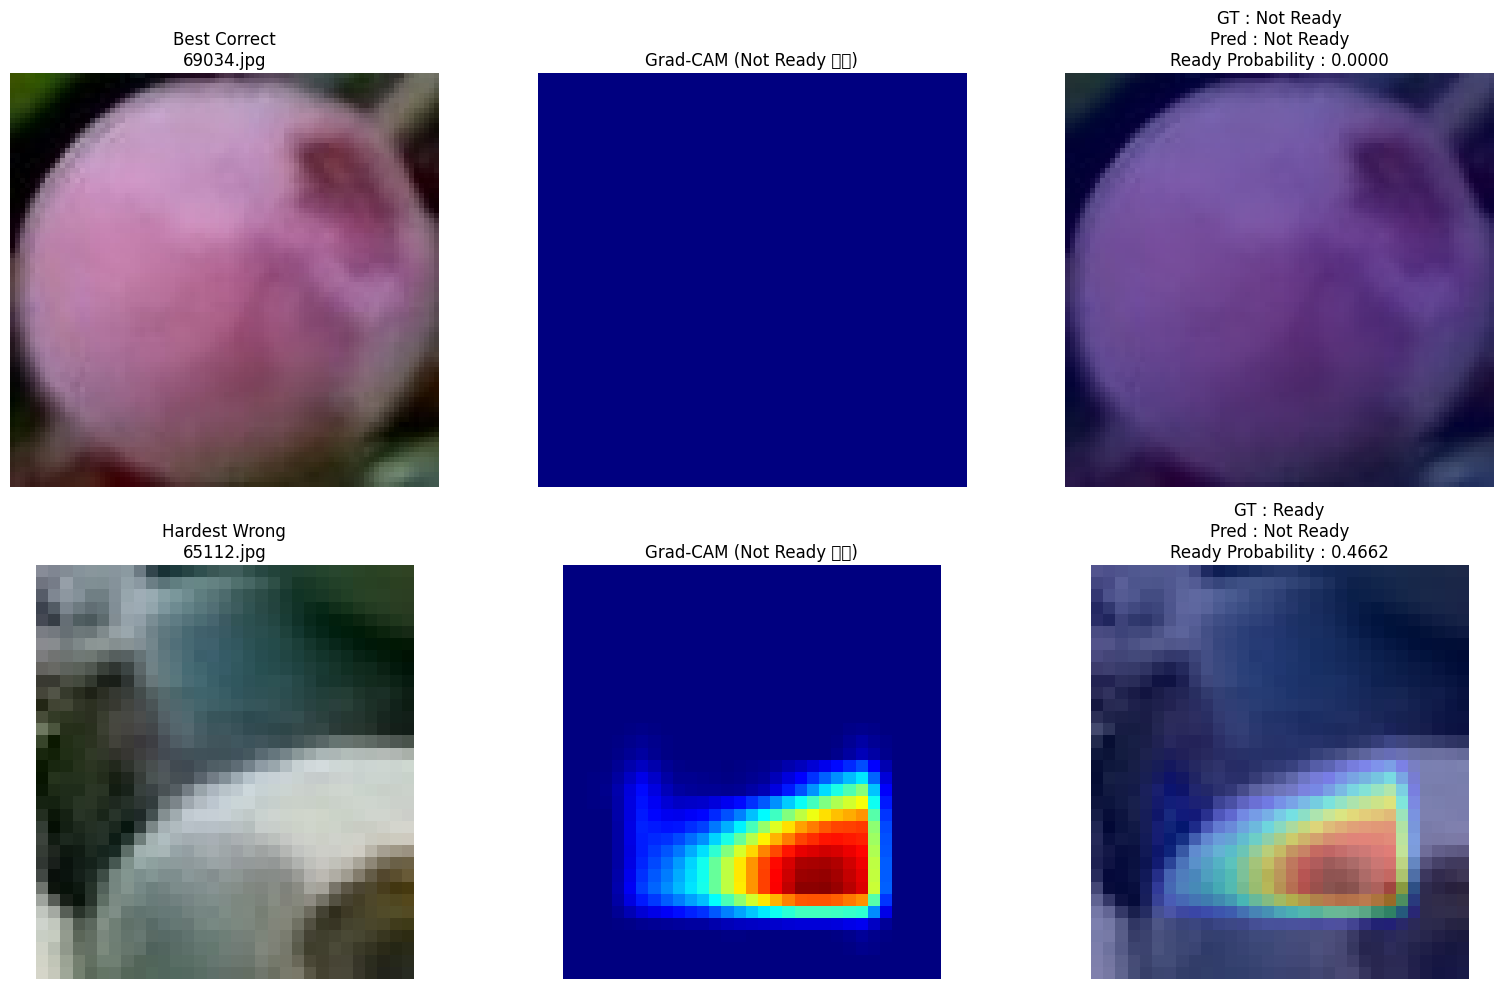

In [33]:
# ==========================================================
# 21. Grad-CAM (tf.data 버전)
# ==========================================================
#
# [변경 1] LAST_CONV_LAYER를 EfficientNet의 "top_conv" 대신
#          새 CNN에서 이름 붙인 마지막 conv layer("last_conv")로 변경.
#          전처리도 preprocess_input 대신 /255.0으로 변경.
#
# [변경 2] "Test 데이터 예측" 셀에서 이미 계산해 둔 pred_prob/pred_label을
#          재사용합니다 (재계산 X). 원래 EfficientNet 노트북에서는 이 셀
#          안에서 model.predict(test_dataset, verbose=0)을 또 실행했는데,
#          진행 상황이 하나도 안 보여서 "멈춘 건지 도는 중인지" 알 수 없는
#          상태로 40분 넘게 걸린 적이 있었습니다. Grad-CAM 자체는 이미지
#          2장만 처리하는 가벼운 연산이니, 굳이 test_dataset 전체를
#          다시 예측할 필요가 없습니다.

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

LAST_CONV_LAYER = "last_conv"


def load_gradcam_image(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    original = image.copy()

    image = cv2.resize(image, IMAGE_SIZE)
    image = image.astype(np.float32)
    image = image / 255.0

    image = np.expand_dims(image, axis=0)

    return original, image


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, target_class):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array, training=False)

        p = tf.cast(predictions[:, 0], tf.float32)
        p = tf.clip_by_value(p, 1e-6, 1.0 - 1e-6)

        logit = tf.math.log(p) - tf.math.log(1.0 - p)

        loss = logit if target_class == 1 else -logit

    grads = tape.gradient(loss, conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # mixed_float16 정책 때문에 conv_output이 float16이다.
    # float16 배열은 cv2.resize에서 에러가 나므로 여기서 float32로 통일.
    conv_output = tf.cast(conv_output[0], tf.float32)
    pooled_grads = tf.cast(pooled_grads, tf.float32)

    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()


def overlay_heatmap(original, heatmap):
    h, w = original.shape[:2]

    heatmap = cv2.resize(heatmap, (w, h))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    return heatmap, overlay


# ==========================================================
# 예측 - [변경 2] 재계산하지 않고 위에서 만든 값을 재사용
# ==========================================================

assert "pred_prob" in dir() and "pred_label" in dir(), \
    "'Test 데이터 예측' 셀을 먼저 실행하세요."

pred_prob = np.asarray(pred_prob).flatten()
pred_label = np.asarray(pred_label).flatten()

print(f"재사용: pred_prob {pred_prob.shape}, pred_label {pred_label.shape}")


# ==========================================================
# 표시할 샘플 고르기
# ==========================================================

display_index = []

correct_idx = np.where(pred_label == test_labels)[0]

if len(correct_idx) > 0:
    correct_conf = np.abs(pred_prob[correct_idx] - 0.5)
    best_correct = correct_idx[np.argmax(correct_conf)]
    display_index.append(("Best Correct", best_correct))

wrong_idx = np.where(pred_label != test_labels)[0]

if len(wrong_idx) == 0:
    print("오분류 이미지가 없습니다.")
else:
    wrong_conf = np.abs(pred_prob[wrong_idx] - 0.5)
    hardest_wrong = wrong_idx[np.argmin(wrong_conf)]
    display_index.append(("Hardest Wrong", hardest_wrong))


# ==========================================================
# 시각화
# ==========================================================

n_rows = len(display_index)

plt.figure(figsize=(16, 5 * n_rows))

for row, (title, idx) in enumerate(display_index):
    print(f"[{row+1}/{n_rows}] {title} 처리 중...")

    filename = os.path.basename(test_files[idx])

    original, img_array = load_gradcam_image(test_files[idx])

    heatmap = make_gradcam_heatmap(
        img_array, model, LAST_CONV_LAYER,
        target_class=int(pred_label[idx])
    )

    heat, overlay = overlay_heatmap(original, heatmap)

    true_label = "Ready" if test_labels[idx] else "Not Ready"
    pred = "Ready" if pred_label[idx] else "Not Ready"
    confidence = pred_prob[idx]

    plt.subplot(n_rows, 3, row * 3 + 1)
    plt.imshow(original)
    plt.title(f"{title}\n{filename}")
    plt.axis("off")

    plt.subplot(n_rows, 3, row * 3 + 2)
    plt.imshow(heat)
    plt.title(f"Grad-CAM ({pred} 근거)")
    plt.axis("off")

    plt.subplot(n_rows, 3, row * 3 + 3)
    plt.imshow(overlay)
    plt.title(f"GT : {true_label}\nPred : {pred}\nReady Probability : {confidence:.4f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

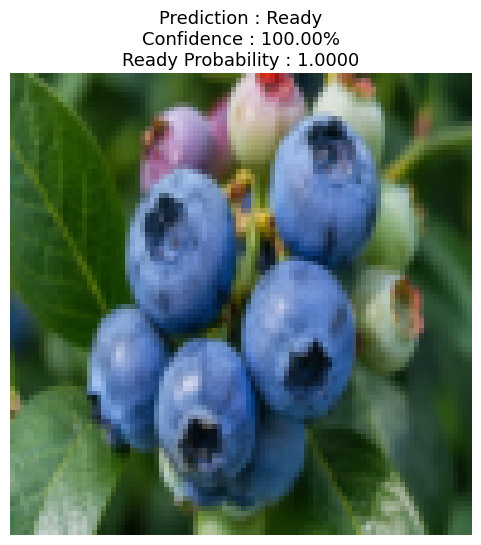

Prediction       : Ready
Confidence       : 100.00%
Ready Probability: 1.0000
Ready Probability (정밀): 0.9999507666
img_array range : 0.0 0.9490196


In [40]:
# ==========================================================
# 22-1. 단일 이미지 예측
# ==========================================================

from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# 예측할 이미지
# ----------------------------------------------------------

IMAGE_PATH = "/content/drive/MyDrive/test.jpg"

# ----------------------------------------------------------
# 이미지 전처리
#
# 학습(셀 6): tf.image.resize -> bilinear
# 여기서도 동일하게 bilinear로 맞춘다 (load_img 기본값은 nearest).
# ----------------------------------------------------------

img = image.load_img(
    IMAGE_PATH,
    target_size=IMAGE_SIZE,
    interpolation="bilinear"
)

img_array = image.img_to_array(img)

# 학습 때와 동일한 전처리 ([0, 1] 정규화)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

"""
<잘못된 전처리>
img_array = img_array.astype("float32")
img_array = img_array / 127.5 - 1
"""

# ----------------------------------------------------------
# 예측
# ----------------------------------------------------------

pred = model.predict(img_array, verbose=0)[0][0]

label = "Ready" if pred >= 0.5 else "Not Ready"

confidence = pred if pred >= 0.5 else 1 - pred

# ----------------------------------------------------------
# 결과 출력
# ----------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(
    f"Prediction : {label}\n"
    f"Confidence : {confidence*100:.2f}%\n"
    f"Ready Probability : {pred:.4f}",
    fontsize=13
)
plt.axis("off")
plt.show()

print("=" * 40)
print("Prediction       :", label)
print(f"Confidence       : {confidence*100:.2f}%")
print(f"Ready Probability: {pred:.4f}")
print("=" * 40)

# 오분류와 차이를 확인하기 위한 코드
print(f"Ready Probability (정밀): {pred:.10f}")
print("img_array range :", img_array.min(), img_array.max())

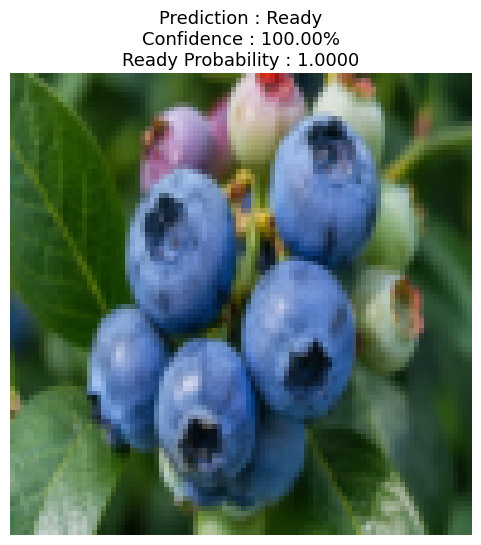

Prediction       : Ready
Confidence       : 100.00%
Ready Probability: 1.0000
Ready Probability (정밀): 1.0000000000
img_array range : -1.0 0.8980392


In [41]:
# ==========================================================
# 22-2. 단일 이미지 예측 오류 예시 - 데이터 전처리의 중요성
# ==========================================================
#
# [참고] 이 CNN은 [0, 1] 범위를 기대하도록 학습했습니다.
#        아래처럼 [-1, 1] 범위(/127.5-1)로 스케일을 잘못 맞추면
#        여전히 값 범위가 어긋나서 예측이 무너집니다.
#        (EfficientNet 버전에서 보여줬던 것과 같은 종류의 실수입니다.)
# ----------------------------------------------------------
# 예측할 이미지
# ----------------------------------------------------------

IMAGE_PATH = "/content/drive/MyDrive/test.jpg"

# ----------------------------------------------------------
# 이미지 전처리
# ----------------------------------------------------------

img = image.load_img(
    IMAGE_PATH,
    target_size=IMAGE_SIZE,
    interpolation="bilinear"
)

img_array = image.img_to_array(img)

# 잘못된 전처리
img_array = img_array.astype("float32")
img_array = img_array / 127.5 - 1

# 배치 차원은 반드시 추가해야 함
img_array = np.expand_dims(img_array, axis=0)

"""
# 학습 때와 동일한 전처리(올바른 전처리)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
"""

# ----------------------------------------------------------
# 예측
# ----------------------------------------------------------

pred = model.predict(img_array, verbose=0)[0][0]

label = "Ready" if pred >= 0.5 else "Not Ready"

confidence = pred if pred >= 0.5 else 1 - pred

# ----------------------------------------------------------
# 결과 출력
# ----------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(
    f"Prediction : {label}\n"
    f"Confidence : {confidence*100:.2f}%\n"
    f"Ready Probability : {pred:.4f}",
    fontsize=13
)
plt.axis("off")
plt.show()

print("=" * 40)
print("Prediction       :", label)
print(f"Confidence       : {confidence*100:.2f}%")
print(f"Ready Probability: {pred:.4f}")
print("=" * 40)

# 오분류와 차이를 확인하기 위한 코드
print(f"Ready Probability (정밀): {pred:.10f}")
print("img_array range :", img_array.min(), img_array.max())

### 전처리 **"/ 255.0 (정상)"** 과 **"/ 125.0 - 1 (오류) "** 의 차이

    "/ 125.0 - 1" 은 ***입력값(전처리한 값)***이 "/ 255.0"에 비해 2배

따라서, 이미지가 쉬울 때는 더 확신(오류가 안 드러나고),

애매한 이미지에서 오류가 드러남(사고를 친다).

대상 이미지 : 3장
예측 완료 : 3장 / 실패 : 0장
          Image Prediction  Confidence (%)  Ready Probability
0  predict1.jpg  Not Ready       54.323256           0.456767
1  predict2.jpg      Ready       59.121394           0.591214
2  predict3.jpg      Ready       92.516685           0.925167

/content/drive/MyDrive/prediction_result_cnn.csv 저장 완료!


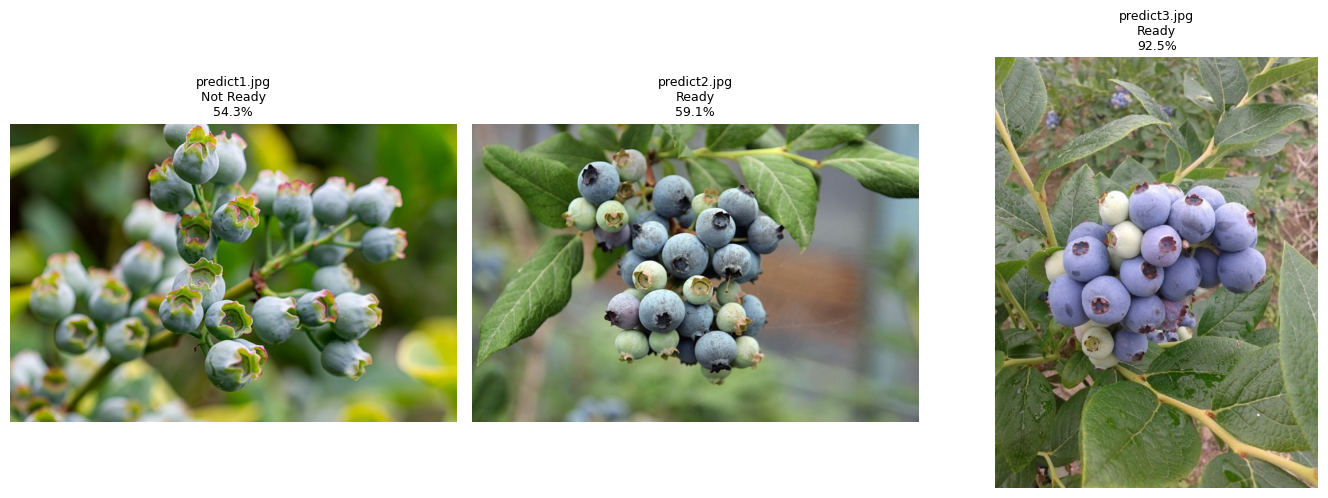


========== Prediction Summary ==========
Total Images : 3
Ready        : 2
Not Ready    : 1


In [36]:
# ==========================================================
# 23. 폴더 예측
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ----------------------------------------------------------
# 설정
# ----------------------------------------------------------

FOLDER_PATH = "/content/drive/MyDrive/predict_folder"

RESULT_CSV = "/content/drive/MyDrive/prediction_result_cnn.csv"

PRED_BATCH = 32
THRESHOLD = 0.5
VALID_EXT = (".jpg", ".jpeg", ".png")

# ----------------------------------------------------------
# 이미지 1장 로드 + 전처리
#
# 학습(셀 6, 8)과 완전히 동일하게 맞춘다.
#  - resize : bilinear (load_img 기본값은 nearest이므로 명시)
#  - 스케일 : [0, 1] 정규화 (/255.0)
# ----------------------------------------------------------

def load_for_predict(path):
    img = image.load_img(
        path,
        target_size=IMAGE_SIZE,
        interpolation="bilinear"
    )

    arr = image.img_to_array(img)
    arr = arr / 255.0

    return arr

# ----------------------------------------------------------
# 대상 파일 목록
# ----------------------------------------------------------

files = sorted(
    f for f in os.listdir(FOLDER_PATH)
    if f.lower().endswith(VALID_EXT)
)

print(f"대상 이미지 : {len(files)}장")

if len(files) == 0:
    raise ValueError(f"{FOLDER_PATH} 안에 예측할 이미지가 없습니다.")

# ----------------------------------------------------------
# 배치 단위 예측
# ----------------------------------------------------------

ok_files = []
probs = []
failed = []

for start in range(0, len(files), PRED_BATCH):
    chunk = files[start:start + PRED_BATCH]

    arrays = []
    names = []

    for f in chunk:
        try:
            arrays.append(load_for_predict(os.path.join(FOLDER_PATH, f)))
            names.append(f)
        except Exception as e:
            failed.append((f, str(e)))

    if len(arrays) == 0:
        continue

    batch = np.stack(arrays)

    p = model.predict(batch, verbose=0).ravel()

    ok_files.extend(names)
    probs.extend(p.tolist())

probs = np.array(probs)

print(f"예측 완료 : {len(ok_files)}장 / 실패 : {len(failed)}장")

for f, msg in failed:
    print(f"  [실패] {f} : {msg}")

# ----------------------------------------------------------
# DataFrame 생성
# ----------------------------------------------------------

labels = np.where(probs >= THRESHOLD, "Ready", "Not Ready")

confidence = np.where(probs >= THRESHOLD, probs, 1 - probs)

result_df = pd.DataFrame({
    "Image": ok_files,
    "Prediction": labels,
    "Confidence (%)": confidence * 100,
    "Ready Probability": probs,
})

print(result_df)

# ----------------------------------------------------------
# CSV 저장
# ----------------------------------------------------------

result_df.to_csv(RESULT_CSV, index=False)

print(f"\n{RESULT_CSV} 저장 완료!")

# ----------------------------------------------------------
# 예측 이미지 갤러리
# ----------------------------------------------------------

show_num = min(9, len(result_df))

plt.figure(figsize=(14, 14))

for i in range(show_num):
    row = result_df.iloc[i]

    img = image.load_img(os.path.join(FOLDER_PATH, row["Image"]))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"{row['Image']}\n{row['Prediction']}\n{row['Confidence (%)']:.1f}%",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 결과 요약
# ----------------------------------------------------------

ready_count = (result_df["Prediction"] == "Ready").sum()
not_ready_count = (result_df["Prediction"] == "Not Ready").sum()

print("\n========== Prediction Summary ==========")
print(f"Total Images : {len(result_df)}")
print(f"Ready        : {ready_count}")
print(f"Not Ready    : {not_ready_count}")
print("========================================")

In [37]:
# ==========================================================
# 24. 모델 저장
# ==========================================================
#
# [변경] EfficientNet 모델과 같은 폴더/파일명을 쓰면 기존에
#        저장해둔 EfficientNet 모델을 덮어쓰게 되므로,
#        CNN 전용 폴더를 따로 둡니다 (두 모델을 나란히 비교할 수 있도록).

import os
import json
import shutil
import pandas as pd

SAVE_DIR = "/content/drive/MyDrive/blueberry_model_cnn"

os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "blueberry_cnn.keras")

# ----------------------------------------------------------
# 모델 저장
#
# 지금 메모리에 있는 model = EarlyStopping이 restore_best_weights로
# 복원한 가중치다. 15~19번의 평가 지표를 만들어낸 모델과 동일하다.
# ----------------------------------------------------------

model.save(MODEL_PATH)

print("모델 저장 완료 :", MODEL_PATH)

# ----------------------------------------------------------
# ModelCheckpoint가 남긴 best 모델도 함께 Drive로 복사
# ----------------------------------------------------------

CKPT_SRC = "best_blueberry_cnn_model.keras"

if os.path.exists(CKPT_SRC):
    shutil.copy(CKPT_SRC, os.path.join(SAVE_DIR, "best_val_accuracy.keras"))
    print("Checkpoint 모델 복사 완료!")
else:
    print("Checkpoint 파일을 찾지 못했습니다 :", CKPT_SRC)

# ----------------------------------------------------------
# 모델 사용 정보 저장
# ----------------------------------------------------------

config = {
    "backbone": "Simple CNN (from scratch, no pretrained weights)",
    "image_size": list(IMAGE_SIZE),
    "threshold": 0.5,
    "class_map": {"0": "Not Ready", "1": "Ready"},
    "preprocess": (
        "resize bilinear -> /255.0 정규화 (EfficientNet의 preprocess_input과 달리 "
        "이 모델은 내장 정규화가 없으므로 직접 [0,1]로 스케일링해야 함)."
    ),
    "saved_weights": "EarlyStopping restore_best_weights 결과 (단일 학습 단계)",
}

with open(os.path.join(SAVE_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("config.json 저장 완료!")

# ----------------------------------------------------------
# 학습 History 저장
# ----------------------------------------------------------

history_df = pd.DataFrame(history.history)

history_df.to_csv(os.path.join(SAVE_DIR, "training_history.csv"), index=False)

print("Training History 저장 완료!")
print(history_df.tail())

모델 저장 완료 : /content/drive/MyDrive/blueberry_model_cnn/blueberry_cnn.keras
Checkpoint 모델 복사 완료!
config.json 저장 완료!
Training History 저장 완료!
    accuracy       auc      loss  precision   recall  val_accuracy   val_auc  \
22  0.970375  0.995290  0.079215   0.972383  0.96825         0.991  0.996960   
23  0.973625  0.995936  0.075574   0.973034  0.97425         0.990  0.996968   
24  0.974625  0.995553  0.077449   0.973087  0.97625         0.990  0.996966   
25  0.975000  0.996034  0.074394   0.972872  0.97725         0.991  0.996962   
26  0.973125  0.994831  0.079254   0.975383  0.97075         0.991  0.996988   

    val_loss  val_precision  val_recall  
22  0.043365        0.99002       0.992  
23  0.043322        0.99000       0.990  
24  0.043600        0.99000       0.990  
25  0.043431        0.99002       0.992  
26  0.043412        0.99002       0.992  


In [38]:
# ==========================================================
# 25. 모델 불러오기
# ==========================================================

import os
import numpy as np
from tensorflow.keras.models import load_model

SAVE_DIR = "/content/drive/MyDrive/blueberry_model_cnn"
MODEL_PATH = os.path.join(SAVE_DIR, "blueberry_cnn.keras")

loaded_model = load_model(MODEL_PATH)

print("모델 불러오기 완료 :", MODEL_PATH)

loaded_model.summary()

# ----------------------------------------------------------
# 저장 / 로드 검증
#
# ※ 이 검증은 24번까지 이어서 실행한 세션에서만 동작한다
#   (원본 model, test_dataset, test_labels가 메모리에 있어야 함)
# ----------------------------------------------------------

orig_prob = model.predict(test_dataset, verbose=0).ravel()
load_prob = loaded_model.predict(test_dataset, verbose=0).ravel()

max_diff = np.abs(orig_prob - load_prob).max()

agree = ((orig_prob >= 0.5) == (load_prob >= 0.5)).mean()

print("\n========== Save / Load 검증 ==========")
print(f"최대 확률 차이 : {max_diff:.6f}")
print(f"판정 일치율    : {agree*100:.2f}%")

if max_diff < 1e-3 and agree == 1.0:
    print("정상 : 저장/로드 과정에서 손실 없음")
else:
    print("경고 : 원본 모델과 결과가 다릅니다. 저장 과정을 확인하세요.")
print("======================================")

# ----------------------------------------------------------
# 불러온 모델의 Test 성능
# ----------------------------------------------------------

loaded_acc = ((load_prob >= 0.5).astype(int) == test_labels).mean()

print(f"\n불러온 모델 Test Accuracy : {loaded_acc:.4f}")

모델 불러오기 완료 : /content/drive/MyDrive/blueberry_model_cnn/blueberry_cnn.keras


Model: "blueberry_simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,240 (2.96 MB)

 Trainable params: 258,177 (1008.50 KB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 516,359 (1.97 MB)


========== Save / Load 검증 ==========
최대 확률 차이 : 0.000000
판정 일치율    : 100.00%
정상 : 저장/로드 과정에서 손실 없음

불러온 모델 Test Accuracy : 0.9790


In [39]:
# ==========================================================
# 26. 최종 보고서 출력
# ==========================================================

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np
import pandas as pd

# ----------------------------------------------------------
# 평가 대상 : Test 데이터
# (Validation은 EarlyStopping/ModelCheckpoint가 모델을 고르는 데
#  이미 사용했으므로, 최종 성능은 한 번도 안 쓴 Test로 보고한다.)
# ----------------------------------------------------------

y_true_test = np.asarray(test_labels).ravel()
y_prob_test = np.asarray(pred_prob).ravel()
y_pred_test = (y_prob_test >= 0.5).astype(int)

# ----------------------------------------------------------
# Metric 계산
# ----------------------------------------------------------

accuracy = accuracy_score(y_true_test, y_pred_test)
precision = precision_score(y_true_test, y_pred_test)
recall = recall_score(y_true_test, y_pred_test)
f1 = f1_score(y_true_test, y_pred_test)
auc_score = roc_auc_score(y_true_test, y_prob_test)
cm = confusion_matrix(y_true_test, y_pred_test)

# ----------------------------------------------------------
# 출력
# ----------------------------------------------------------

print("=" * 60)
print(" Blueberry Ripeness Classification Report (Simple CNN, Test set) ")
print("=" * 60)
print(f"Test 이미지 수 : {len(y_true_test)}")
print("-" * 60)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"AUC       : {auc_score:.4f}")
print("=" * 60)

print("\nClassification Report\n")
print(classification_report(
    y_true_test, y_pred_test,
    target_names=["Not Ready", "Ready"],
    digits=4
))

print("=" * 60)
print("\nConfusion Matrix")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\n  TN (Not Ready를 Not Ready로) : {tn}")
print(f"  FP (Not Ready를 Ready로)     : {fp}")
print(f"  FN (Ready를 Not Ready로)     : {fn}")
print(f"  TP (Ready를 Ready로)         : {tp}")
print("=" * 60)

# ----------------------------------------------------------
# Validation vs Test 비교
# ----------------------------------------------------------

y_true_val = np.asarray(y_true).ravel()
y_prob_val = np.asarray(y_prob).ravel()
y_pred_val = (y_prob_val >= 0.5).astype(int)

compare_df = pd.DataFrame(
    {
        "Validation": [
            accuracy_score(y_true_val, y_pred_val),
            precision_score(y_true_val, y_pred_val),
            recall_score(y_true_val, y_pred_val),
            f1_score(y_true_val, y_pred_val),
            roc_auc_score(y_true_val, y_prob_val),
        ],
        "Test": [accuracy, precision, recall, f1, auc_score],
    },
    index=["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
)

print("\n========== Validation vs Test ==========")
print(compare_df.round(4))
print("========================================")

 Blueberry Ripeness Classification Report (Simple CNN, Test set) 
Test 이미지 수 : 1000
------------------------------------------------------------
Accuracy  : 0.9790
Precision : 0.9724
Recall    : 0.9860
F1-score  : 0.9791
AUC       : 0.9974

Classification Report

              precision    recall  f1-score   support

   Not Ready     0.9858    0.9720    0.9789       500
       Ready     0.9724    0.9860    0.9791       500

    accuracy                         0.9790      1000
   macro avg     0.9791    0.9790    0.9790      1000
weighted avg     0.9791    0.9790    0.9790      1000


Confusion Matrix
[[486  14]
 [  7 493]]

  TN (Not Ready를 Not Ready로) : 486
  FP (Not Ready를 Ready로)     : 14
  FN (Ready를 Not Ready로)     : 7
  TP (Ready를 Ready로)         : 493

========== Validation vs Test ==========
           Validation    Test
Accuracy       0.9910  0.9790
Precision      0.9900  0.9724
Recall         0.9920  0.9860
F1-score       0.9910  0.9791
AUC            0.9979  0.9974
